In [32]:
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from mcDETECT.utils import *
from scipy import sparse
from sklearn.metrics import adjusted_rand_score
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings("ignore")
sc.settings.verbosity = 0

In [33]:
color_dct = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
color_cts = clr.LinearSegmentedColormap.from_list("magma", ["#000003", "#3B0F6F", "#8C2980", "#F66E5B", "#FD9F6C", "#FBFCBF"], N=256)

In [34]:
sample = "Xenium_5K_BC"

# Paths
intermediate_path = f"../../data/{sample}/intermediate_data/"
processed_path = f"../../data/{sample}/processed_data/"
output_path = f"../../output/1_exploration/{sample}/"

In [35]:
# Read data
adata = sc.read_h5ad(intermediate_path + "adata.h5ad")
cell_ids = np.load(processed_path + "cell_ids.npy", allow_pickle=True)
assert adata.shape[0] > cell_ids.shape[0], "cell_ids should be a subset of adata.obs_names"
adata_tumor = adata[adata.obs["cell_id"].isin(cell_ids)].copy()

adata_tumor_cyto = sc.read_h5ad(output_path + "adata_cytoplasmic_shared3_embedded.h5ad")
assert adata_tumor.shape[0] == adata_tumor_cyto.shape[0], "adata_tumor and adata_tumor_cyto should have the same number of cells"

In [36]:
# Clustering
res_cyto = 0.8
sc.tl.louvain(adata_tumor_cyto, resolution = res_cyto, key_added = "subtype_louvain")
adata_tumor.obs["subtype_louvain_cyto"] = adata_tumor_cyto.obs["subtype_louvain"].values
print(f"Number of clusters (cytoplasmic): {adata_tumor.obs['subtype_louvain_cyto'].nunique()}")

Number of clusters (cytoplasmic): 5


In [37]:
# UMAP plot
sc.set_figure_params(figsize = (8, 8))
ax = sc.pl.umap(adata_tumor_cyto, color="subtype_louvain", size=10, show=False, title="Cytoplasmic expression")
plt.savefig(output_path + "umap_clustering.png", dpi=300, bbox_inches="tight")
plt.close()

In [38]:
# Scatter plot
sc.set_figure_params(figsize = (7, 12))
ax = sc.pl.scatter(adata_tumor, x = "global_x", y = "global_y", color = "subtype_louvain_cyto", palette = color_dct, size = 2.5, alpha = 1, show = False)
ax.grid(False)
plt.savefig(output_path + "scatter.png", dpi = 300, bbox_inches = "tight")
plt.close()

subtypes = adata_tumor.obs["subtype_louvain_cyto"].astype(str)

for subtype in sorted(subtypes.unique(), key=int):

    is_target = subtypes == subtype

    fig, ax = plt.subplots(figsize=(7, 12))

    # Plot all other tumor cells first
    ax.scatter(adata_tumor.obs.loc[~is_target, "global_x"], adata_tumor.obs.loc[~is_target, "global_y"], c="lightgray", s=0.5, alpha=0.8, linewidths=0)

    # Plot target subtype on top
    ax.scatter(adata_tumor.obs.loc[is_target, "global_x"], adata_tumor.obs.loc[is_target, "global_y"], c=color_dct[int(subtype)], s=1, alpha=0.8, linewidths=0)

    ax.grid(False)
    ax.set_xlabel("global_x")
    ax.set_ylabel("global_y")
    ax.set_title(f"Subtype {subtype}")

    plt.savefig(output_path + f"scatter_{subtype}.png", dpi=300, bbox_inches="tight")
    plt.close()

In [39]:
spatial_programs = {"immune_cell": ["CD4+ T cell", "CD8+ T cell", "T cell", "B cell", "Dendritic cell", "Myeloid cell", "Mast cell"],
                    "tcell": ["CD4+ T cell", "CD8+ T cell", "T cell"]}

subtypes = adata_tumor.obs["subtype_louvain_cyto"].astype(str)

for program_name, cell_types in spatial_programs.items():
    
    adata_immune = adata[adata.obs["cell_type_merged"].isin(cell_types)].copy()

    for subtype in sorted(subtypes.unique(), key=int):

        is_target = subtypes == subtype

        fig, ax = plt.subplots(figsize=(7, 12))

        # Plot all immune cells as the common background
        ax.scatter(adata_immune.obs["global_x"], adata_immune.obs["global_y"], c="lightgray", s=0.5, alpha=0.8, linewidths=0)

        # Plot only the target tumor subtype on top
        ax.scatter(adata_tumor.obs.loc[is_target, "global_x"], adata_tumor.obs.loc[is_target, "global_y"], c=color_dct[int(subtype)], s=1, alpha=0.8, linewidths=0)

        ax.grid(False)
        ax.set_xlabel("global_x")
        ax.set_ylabel("global_y")
        ax.set_title(f"Tumor subtype {subtype}")
        plt.savefig(output_path + f"scatter_{subtype}_{program_name}.png", dpi=300, bbox_inches="tight")
        plt.close()

## DE analysis

In [47]:
sc.tl.rank_genes_groups(
    adata_tumor,
    groupby="subtype_louvain_cyto",
    method="wilcoxon",
    use_raw=False
)

result = adata_tumor.uns["rank_genes_groups"]

names = pd.DataFrame(result["names"])
logfc = pd.DataFrame(result["logfoldchanges"])
pvals = pd.DataFrame(result["pvals"])
pvals_adj = pd.DataFrame(result["pvals_adj"])
scores = pd.DataFrame(result["scores"])

for i in names.columns:

    df = pd.DataFrame({
        "names": names[i],
        "score": scores[i],
        "logfc": logfc[i],
        "pvals": pvals[i],
        "pvals_adj": pvals_adj[i]
    })

    df = df[
        (df["logfc"] > 0) &
        (df["pvals_adj"] < 0.05)
    ]

    df = df.sort_values("logfc", ascending=False)

    df.to_csv(
        output_path + f"DE_cytoplasmic_cluster_{i}.csv",
        index=False
    )

In [43]:
adata_tumor_cyto.obs["subtype_louvain"].value_counts()

subtype_louvain
0    29712
1    26240
2    24212
3    15267
4     6749
Name: count, dtype: int64

In [44]:
cluster = "3"

df = pd.DataFrame({
    "names": names[cluster],
    "score": scores[cluster],
    "logfc": logfc[cluster],
    "pvals": pvals[cluster],
    "pvals_adj": pvals_adj[cluster]
})

df.head(30)

,names,score,logfc,pvals,pvals_adj
0,XBP1,69.079483,1.673900,0.000000,0.000000
1,TLR4,0.028613,0.382430,0.977173,0.977173
2,NXPH4,-0.039825,-0.043778,0.968232,0.969091
3,CFH,-0.046400,-0.187602,0.962992,0.964701
4,TSPYL5,-0.047768,-0.038523,0.961901,0.964464
5,CDK6,-0.048919,-0.127430,0.960984,0.964401
6,CAVIN3,-0.068632,-1.030167,0.945283,0.949488
7,LOX,-0.069072,-0.138200,0.944932,0.949488
8,IGF1,-0.075682,-0.365142,0.939672,0.945534
9,TSPAN12,-0.075915,-0.575239,0.939487,0.945534


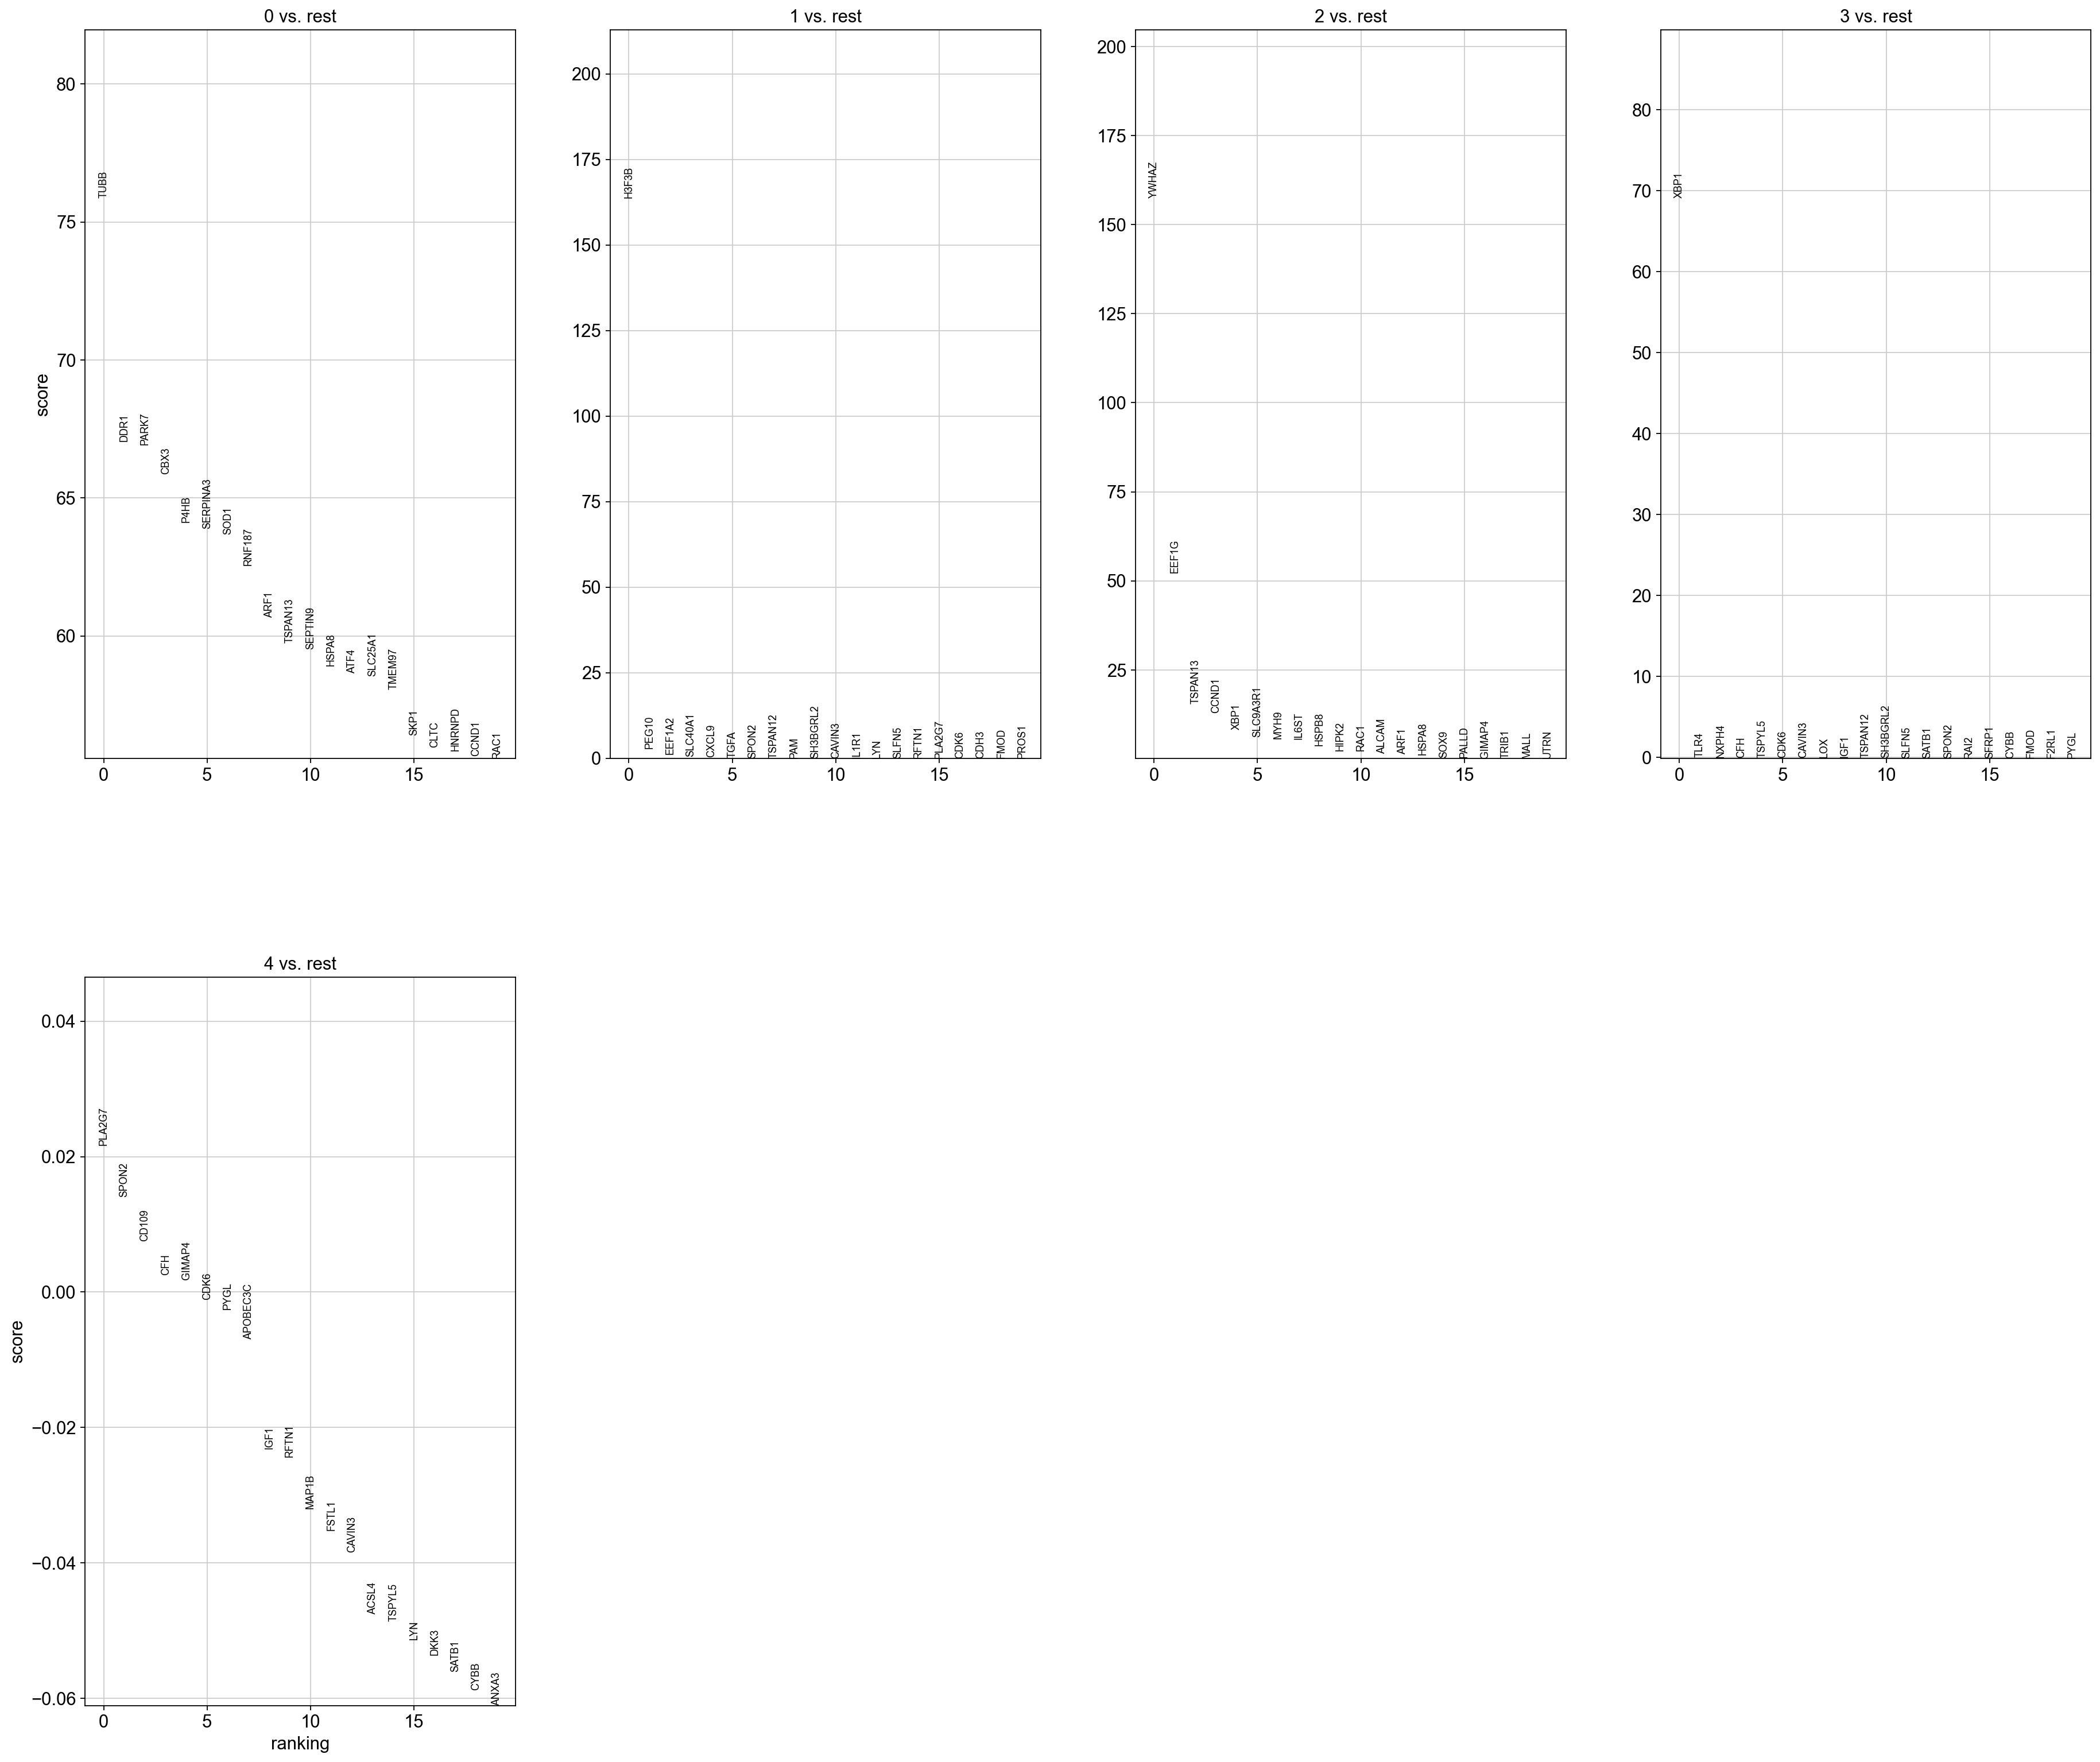

In [45]:
sc.pl.rank_genes_groups(
    adata_tumor_cyto,
    n_genes=20,
    sharey=False
)

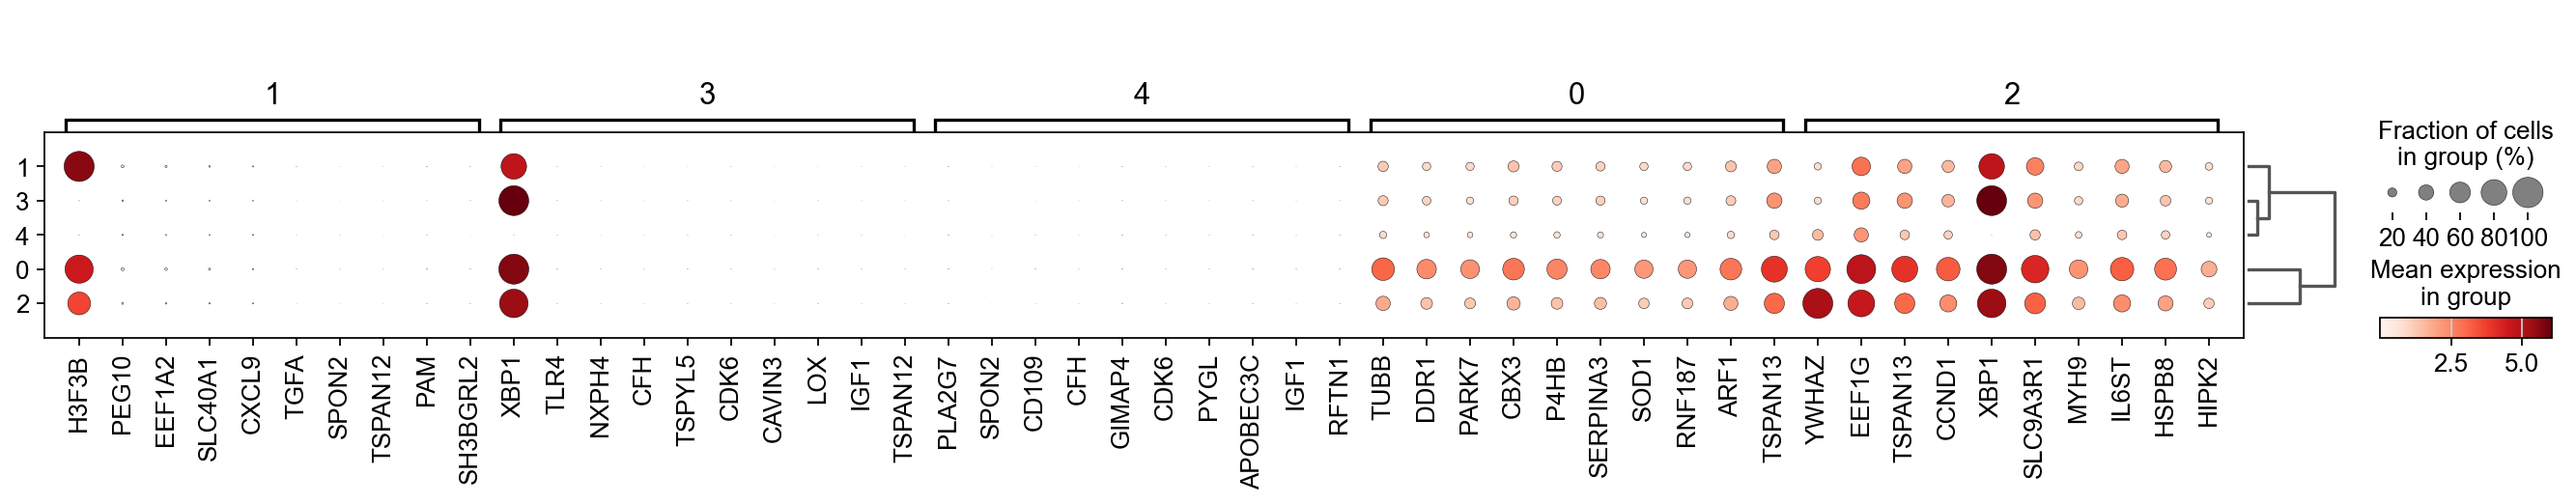

In [46]:
sc.pl.rank_genes_groups_dotplot(
    adata_tumor_cyto,
    n_genes=10,
    groupby="subtype_louvain"
)

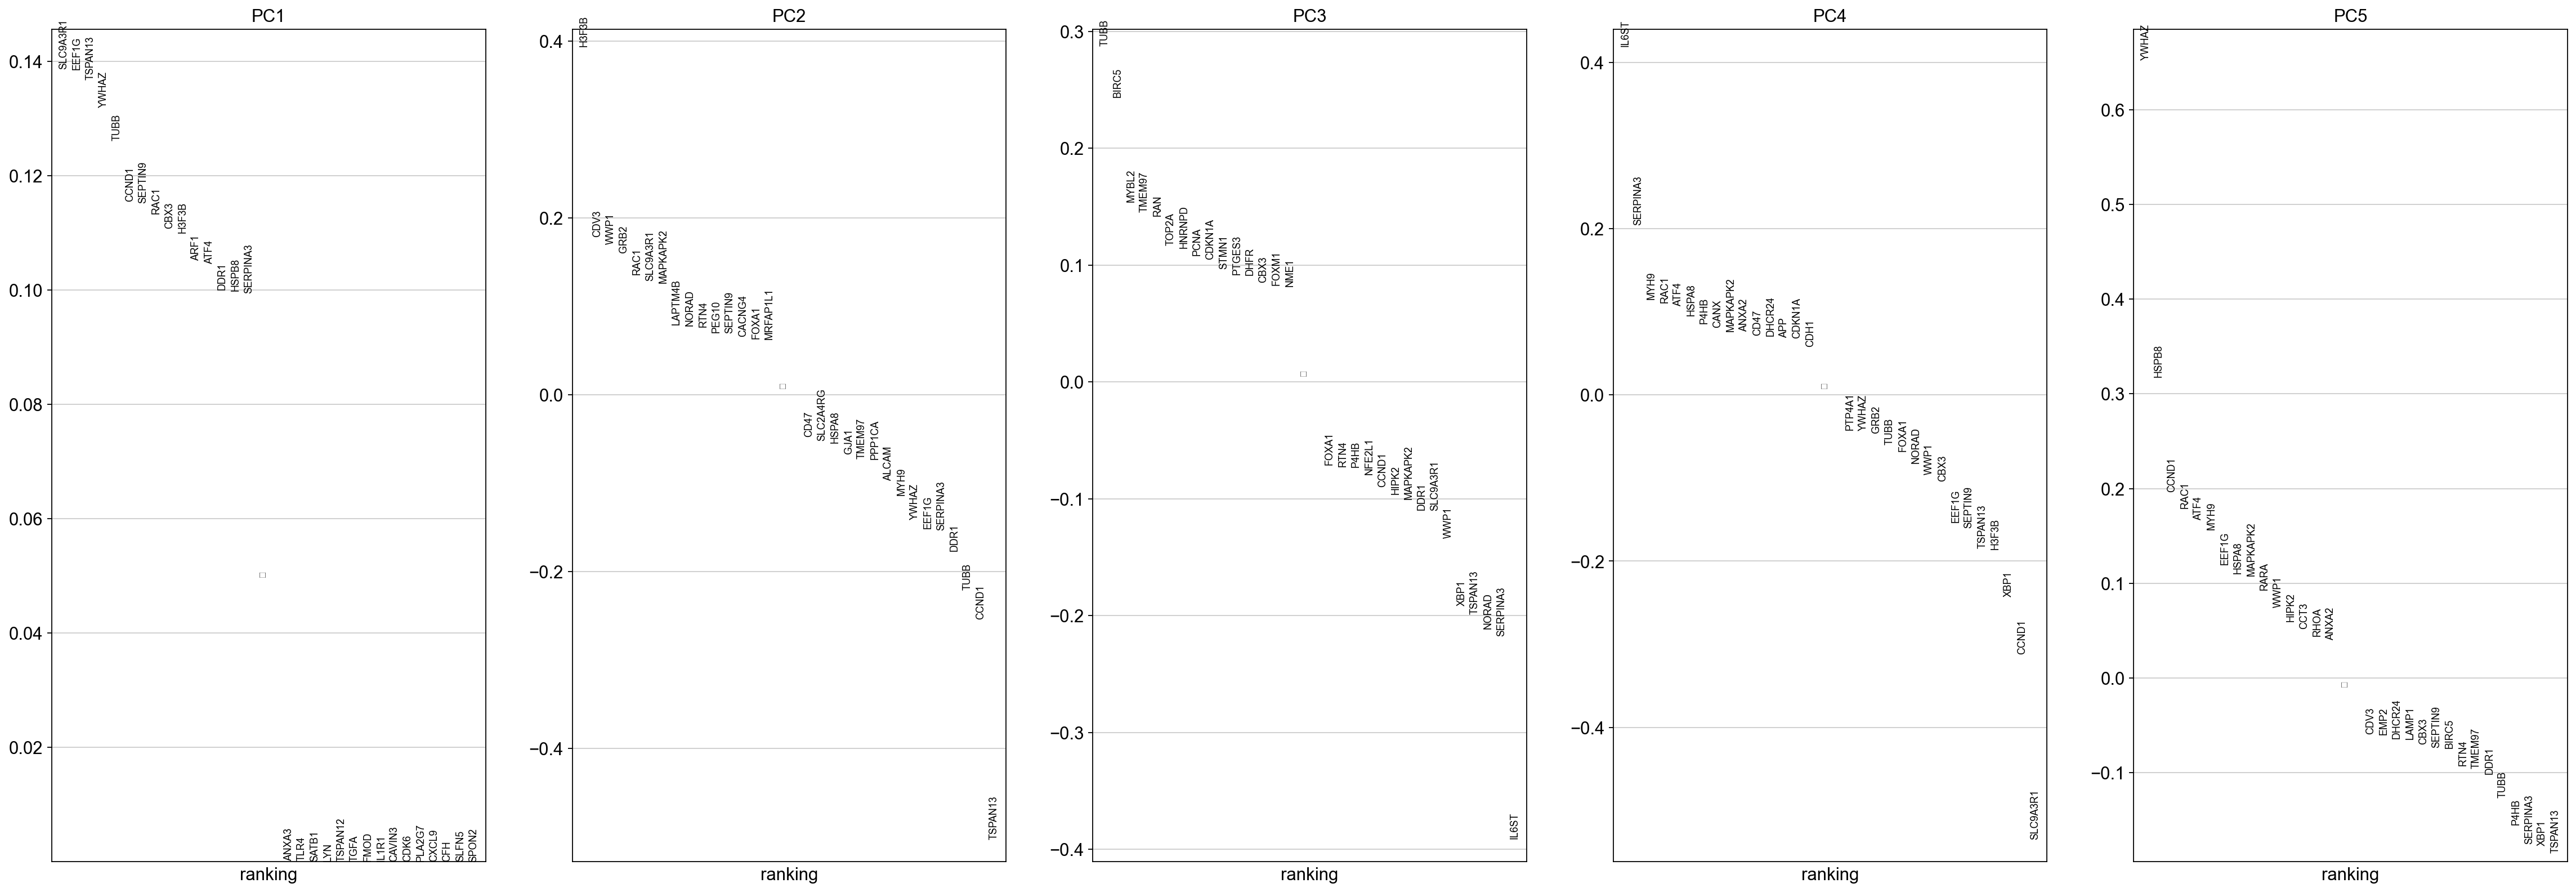

In [48]:
sc.pl.pca_loadings(
    adata_tumor_cyto,
    components=[1, 2, 3, 4, 5]
)